# Introduction

# Liturature

# Data

In [ ]:
import pandas as pd

df = pd.read_csv("../../Data/combinedWeekly_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True) #re-indexes at zero

In [ ]:
print(df.head())
print(df.tail())
print(df.columns)
print(df.shape)

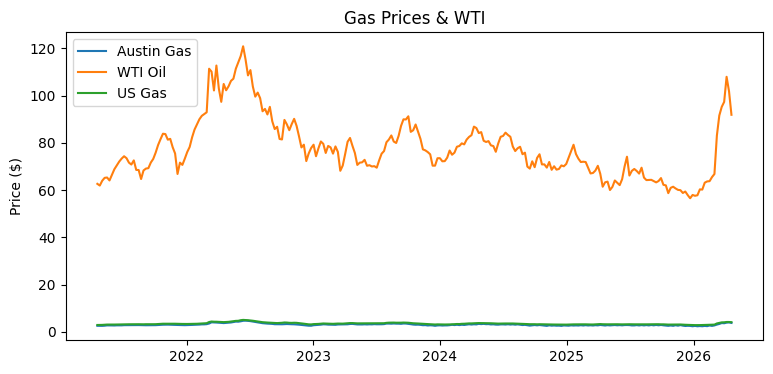

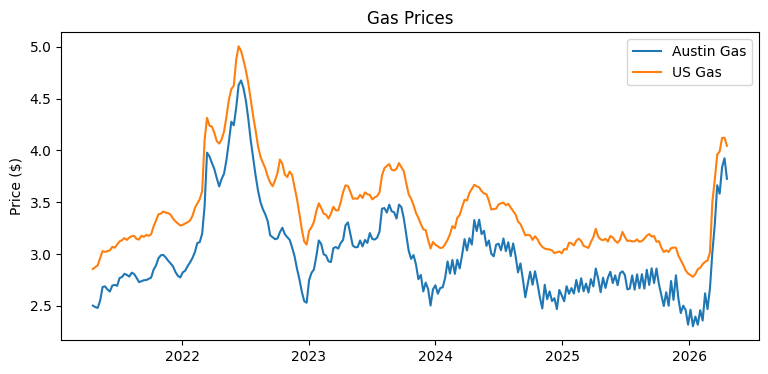

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))

plt.plot(df["date"], df["gas_price"], label="Austin Gas")
plt.plot(df["date"], df["wti_price"], label="WTI Oil")
plt.plot(df["date"], df["national_gas_price"], label="US Gas")

plt.legend()
plt.title("Gas Prices & WTI")
plt.ylabel("Price ($)")
plt.show()

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["gas_price"], label="Austin Gas")
plt.plot(df["date"], df["national_gas_price"], label="US Gas")

plt.legend()
plt.title("Gas Prices")
plt.ylabel("Price ($)")
plt.show()

Austin gas prices appear more volatile than the national average, which makes sense. The US series is an average across many locations, so it smooths out local shocks and short-term fluctuations. In contrast, Austin reflects a single market, so local supply or demand changes show up more directly. Because of this, the Austin series naturally shows more variation over time compared to the smoother national benchmark.

(see data/qualityCheck.ipynb for more)

# Preliminary tests

### Non-stationarity at i(0)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name, reg_type="c"):
    result = adfuller(series.dropna(), regression=reg_type)
    print(name)
    print("ADF Stat:", round(result[0], 5))
    print("p-value:", round(result[1], 5))
    print("-"*30) #prints dashed lines/readability

# Random walk (with constant/ mean != zero)) v.s. Stationarity
adf_test(df["gas_price"], "Austin Gas (drift)", "c")
adf_test(df["wti_price"], "WTI (drift)", "c")
adf_test(df["national_gas_price"], "National Gas (drift)", "c")

# Random walk with drift v.s. Determinstic trend (Trend Stationary) w/ constant
adf_test(df["gas_price"], "Austin Gas (trend)", "ct")
adf_test(df["wti_price"], "WTI (trend)", "ct")
adf_test(df["national_gas_price"], "National Gas (trend)", "ct")

Austin Gas (drift)
ADF Stat: -2.80734
p-value: 0.05723
------------------------------
WTI (drift)
ADF Stat: -2.79985
p-value: 0.05829
------------------------------
National Gas (drift)
ADF Stat: -2.7556
p-value: 0.0649
------------------------------
Austin Gas (trend)
ADF Stat: -2.97404
p-value: 0.13949
------------------------------
WTI (trend)
ADF Stat: -3.16239
p-value: 0.09216
------------------------------
National Gas (trend)
ADF Stat: -2.96721
p-value: 0.14148
------------------------------


I ran the ADF test with a constant to allow for stationarity around a non-zero mean, which is appropriate for price data. I fail to reject the null of a unit root for all series, suggesting they behave like random walks at I(0). I also include a trend specification as a robustness check, and the results remain consistent.

To co-integrated we need the sereis to be stationary at I(1), after the first difference (becasue we have random walk and no trend).

First difference:
$$
y_t = \alpha + y_{t-1} + \varepsilon_t
$$

$$
LHS: \Delta y_t = y_t - y_{t-1}
$$
$$
RHS: \alpha + \varepsilon_t = (\alpha + y_{t-1} + \varepsilon_t) - y_{t-1}
$$

$$
\Delta y_t = \alpha + \varepsilon_t
$$

### Stationarity at i(1)

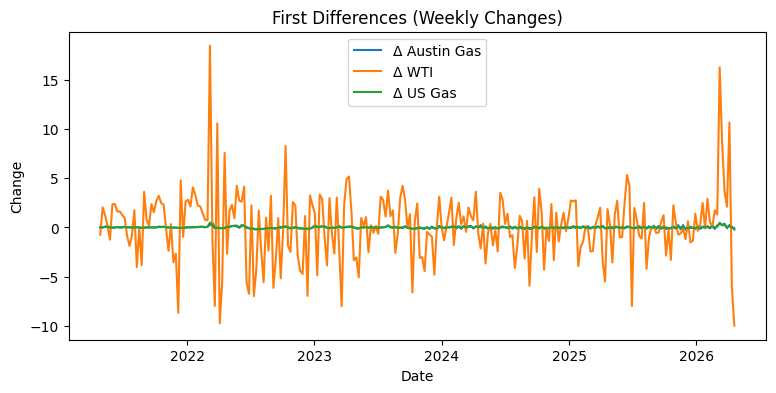

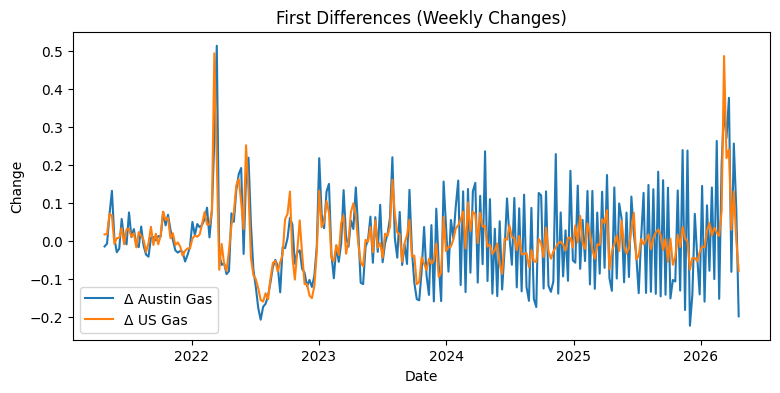

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["d_gas"], label="Δ Austin Gas")
plt.plot(df["date"], df["d_wti"], label="Δ WTI")
plt.plot(df["date"], df["d_nat"], label="Δ US Gas")

plt.legend()
plt.title("First Differences (Weekly Changes)")
plt.xlabel("Date")
plt.ylabel("Change")
plt.show()

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["d_gas"], label="Δ Austin Gas")
plt.plot(df["date"], df["d_nat"], label="Δ US Gas")

plt.legend()
plt.title("First Differences (Weekly Changes)")
plt.xlabel("Date")
plt.ylabel("Change")
plt.show()

In [27]:
df["d_gas"] = df["gas_price"].diff()
df["d_wti"] = df["wti_price"].diff()
df["d_nat"] = df["national_gas_price"].diff()

adf_test(df["d_gas"], "Δ Austin Gas", "c")
adf_test(df["d_wti"], "Δ WTI", "c")
adf_test(df["d_nat"], "Δ National Gas", "c")

Δ Austin Gas
ADF Stat: -8.36481
p-value: 0.0
------------------------------
Δ WTI
ADF Stat: -7.40795
p-value: 0.0
------------------------------
Δ National Gas
ADF Stat: -8.59496
p-value: 0.0
------------------------------


We have confirmed that all series are non-stationary in levels but become stationary after first differencing, indicating they are likely I(1). This allows us to proceed with testing for a long-run equilibrium relationship between gasoline prices and oil prices using a cointegration framework.

The next step is to estimate the long-run relationship (e.g., via Engle-Granger) and obtain the residuals, which will serve as the error correction term. If the residuals are stationary, this confirms cointegration and justifies estimating an Error Correction Model (ECM) to capture both long-run equilibrium behavior and short-run dynamics.

### Addressing Volitilty and Pricing Cycle

The observed volatility in Austin gas prices is driven by a combination of real pricing behavior and measurement differences. The Austin series is constructed from daily station-level data and captures weekly pricing cycles, while the national series is a Monday snapshot, which smooths these fluctuations. This makes Austin appear more volatile by construction.

However, the increase in volatility after 2024 cannot be explained by measurement alone. Since the data collection method remains consistent over time and similar increases are not observed in all cities, the evidence points to a real change in pricing dynamics, such as stronger pass-through and more aggressive price adjustments.

To account for this:

Use weekly averages: Aligns gasoline data with oil prices and reduces cycle-driven noise
Include a post-2024 indicator: Captures changes in volatility and pass-through
Allow parameter variation: Estimate separate periods or include interaction terms

Overall, the goal is not to remove the volatility, but to properly account for both measurement structure and underlying economic behavior.

### Next Steps: From Stationarity to ECM

We have established that all series are I(1), meaning they are non-stationary in levels but stationary in first differences. This allows us to proceed with testing for a long-run equilibrium relationship between gasoline prices and oil prices.

The next step is to estimate the long-run relationship using an Engle-Granger approach:

* Estimate the long-run equation (levels):
Regress gasoline prices on oil prices to obtain the equilibrium relationship.

* Test residuals for stationarity:
If the residuals are stationary, this confirms cointegration.

* Construct the Error Correction Model (ECM):
Use the lagged residuals as the error correction term to model short-run dynamics.

* Account for structural changes:
Given the increase in volatility after 2024, allow for changes in short-run dynamics by:
    * Splitting the sample (pre/post-2024), or
    * Including interaction terms or a post-2024 dummy

This framework allows us to separate long-run equilibrium behavior from short-run adjustments while accounting for changes in pricing dynamics.

# The Long-run relationship & Co-Integration 

## Austin Gasoline and TWI oil

### Long-Run Relationship (Engle-Granger Step 1)

As mentioned, the first step in testing for cointegration in the Engle-Granger framework is to estimate the long-run relationship via OLS.

We estimate:

$$
gas_t = \alpha + \beta \cdot WTI_t + u_t
$$

where:

- \( gas_t \) is the retail gasoline price (Austin)  
- \( WTI_t \) is the crude oil price  
- \( u_t \) is the long-run equilibrium error  

If \( gas_t \) and \( WTI_t \) are cointegrated, the residuals \( u_t \) should be stationary.

This will be tested in the next step.

In [39]:
import statsmodels.api as sm

# make sure no missing values
ecm_df = df[["gas_price", "wti_price"]].dropna()

# dependent and independent variables
y = ecm_df["gas_price"]
X = sm.add_constant(ecm_df["wti_price"])

# estimate long-run model
long_run_model = sm.OLS(y, X).fit()

# print results
print(long_run_model.summary())

                            OLS Regression Results                            
Dep. Variable:              gas_price   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     1027.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.65e-92
Time:                        18:07:42   Log-Likelihood:                 53.590
No. Observations:                 262   AIC:                            -103.2
Df Residuals:                     260   BIC:                            -96.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6218      0.075      8.301      0.0

A $1 increase in WTI → approx. 3 cent increase in gas prices (long-run)

### Cointegration Test (Engle-Granger Step 2)

We test whether the residuals from the long-run relationship are stationary using the Augmented Dickey-Fuller (ADF) test.

If the residuals are stationary, this confirms that gasoline and oil prices are cointegrated, meaning they share a stable long-run equilibrium relationship.

In [40]:
from statsmodels.tsa.stattools import adfuller

# extract residuals
ecm_df["residuals"] = long_run_model.resid

# ADF test on residuals (NO constant)
adf_result = adfuller(ecm_df["residuals"], regression="n")

print("ADF Stat:", adf_result[0])
print("p-value:", adf_result[1])

ADF Stat: -3.829714743102182
p-value: 0.00014203413849593117


As seen above: the residuals are stationary (highly significant) 
    
-> There likely exists a stable long-run equilibrium relationship between Austin gasoline and WTI oil prices.

## U.S. Gasoline and TWI oil

### Engle-Grager Steps 1 & 2

Engle–Granger Steps (U.S. Gasoline & WTI)

We repeat the Engle–Granger two-step procedure for U.S. gasoline prices and WTI oil prices.

**Step 1:** Estimate the long-run relationship in levels:

$$
gas^{US}_t = \alpha + \beta \cdot WTI_t + u_t
$$

**Step 2:** Test the residuals \(u_t\) for stationarity using the ADF test.

If the residuals are stationary, this indicates that U.S. gasoline and oil prices are cointegrated and share a stable long-run relationship.

In [41]:
# Step 1: Long-run regression
us_df = df[["national_gas_price", "wti_price"]].dropna()

y = us_df["national_gas_price"]
X = sm.add_constant(us_df["wti_price"])

us_lr_model = sm.OLS(y, X).fit()

# Step 2: ADF test on residuals
from statsmodels.tsa.stattools import adfuller

us_resid = us_lr_model.resid
adf_result = adfuller(us_resid, regression="n")

print("ADF Stat:", adf_result[0])
print("p-value:", adf_result[1])

ADF Stat: -4.086394340129231
p-value: 5.199240653875441e-05


# Error-Correction Model (ECM)

## Math Proof


We begin with the estimated long-run relationship:

\begin{equation}
gas_t = \alpha + \beta WTI_t + u_t
\tag{1}
\end{equation}

Rearranging:

\begin{equation}
u_t = gas_t - \alpha - \beta WTI_t
\tag{2}
\end{equation}

This residual measures how far gasoline prices are from their long-run equilibrium with oil prices.

Lag the residual one period:

\begin{equation}
u_{t-1} = gas_{t-1} - \alpha - \beta WTI_{t-1}
\tag{3}
\end{equation}

Define weekly changes:

\begin{equation}
\Delta gas_t = gas_t - gas_{t-1}
\tag{4}
\end{equation}

\begin{equation}
\Delta WTI_t = WTI_t - WTI_{t-1}
\tag{5}
\end{equation}

Now write the long-run relationship at time \(t\) and \(t-1\):

\begin{equation}
gas_t = \alpha + \beta WTI_t + u_t
\tag{6}
\end{equation}

\begin{equation}
gas_{t-1} = \alpha + \beta WTI_{t-1} + u_{t-1}
\tag{7}
\end{equation}

Subtract (7) from (6):

\begin{equation}
gas_t - gas_{t-1} = \beta (WTI_t - WTI_{t-1}) + (u_t - u_{t-1})
\tag{8}
\end{equation}

Using difference notation from (4) and (5):

\begin{equation}
\Delta gas_t = \beta \Delta WTI_t + (u_t - u_{t-1})
\tag{9}
\end{equation}

Now impose that deviations from equilibrium correct over time:

\begin{equation}
u_t - u_{t-1} = -\gamma u_{t-1} + \varepsilon_t
\tag{10}
\end{equation}

Substitute (10) into (9):

\begin{equation}
\Delta gas_t = \beta \Delta WTI_t - \gamma u_{t-1} + \varepsilon_t
\tag{11}
\end{equation}

Adding a constant term gives the standard ECM:

\begin{equation}
\Delta gas_t = c + \beta_1 \Delta WTI_t + \gamma u_{t-1} + \varepsilon_t
\tag{12}
\end{equation}

Substituting (3) directly into (12):

\begin{equation}
\Delta gas_t = c + \beta_1 \Delta WTI_t + \gamma (gas_{t-1} - \alpha - \beta WTI_{t-1}) + \varepsilon_t
\tag{13}
\end{equation}

#### Variable Definitions


- $gas_t$:   retail gasoline price (Austin)  
- $WTI_t$:   crude oil price  
- $\Delta gas_t$:    change in gasoline prices (from equation (4))  
- $\Delta WTI_t$:    change in oil prices (from equation (5))  
- $u_t$:     long-run equilibrium error (from equation (2))  
- $u_{t-1}$:     lagged equilibrium error (from equation (3))  
- $\gamma$:      speed of adjustment back to equilibrium  
- $\varepsilon_t$:   short-run shock  

## ECM Model (Emperical Specification)

From equation (13), gasoline price changes are driven by two components:

- **Short-run oil price changes:** $ \Delta WTI_t $  
  This captures immediate movements in crude oil prices. The coefficient $ \beta_1 $ measures the **short-run pass-through**, i.e., how much gasoline prices change in response to a one-unit change in oil prices within the same period.

- **Long-run disequilibrium (error correction term):** $ u_{t-1} $  
  This represents the deviation of gasoline prices from their long-run equilibrium with oil prices in the previous period:
  $$
  u_{t-1} = gas_{t-1} - \alpha - \beta WTI_{t-1}
  $$
  The coefficient $ \gamma $ measures the **speed of adjustment** back to equilibrium.

Interpretation of $ \gamma $:

- If $ \gamma < 0 $, gasoline prices adjust back toward the long-run equilibrium after a deviation  
- The magnitude of $ \gamma $ determines how quickly this adjustment occurs  
- For example, $ \gamma = -0.2 $ implies that approximately 20% of the deviation from equilibrium is corrected each period  

Together, $ \beta_1 $ and $ \gamma $ separate:

- **Short-run dynamics** (immediate response to oil price changes)  
- **Long-run adjustment** (correction toward equilibrium)

## ECM Model (Austin)

#### ECM variable Creation

In [35]:
# residuals from long-run model
ecm_df["u_t"] = long_run_model.resid

# first differences
ecm_df["d_gas"] = ecm_df["gas_price"].diff()
ecm_df["d_wti"] = ecm_df["wti_price"].diff()

# Lag of error correction term
ecm_df["u_lag"] = ecm_df["u_t"].shift(1)

# Drop missing values from differencing and lagging
ecm_model_df = ecm_df.dropna()

print(ecm_model_df.head())

   gas_price  wti_price  residuals       u_t     d_gas  d_wti     u_lag
1   2.486500     61.920  -0.026156 -0.026156 -0.014667 -0.732 -0.033843
2   2.479333     63.960  -0.095619 -0.095619 -0.007167  2.040 -0.026156
3   2.549000     65.192  -0.063574 -0.063574  0.069667  1.232 -0.095619
4   2.680833     65.330   0.064045  0.064045  0.131833  0.138 -0.063574
5   2.687286     64.092   0.108303  0.108303  0.006452 -1.238  0.064045


#### ECM regression

In [36]:
y = ecm_model_df["d_gas"]

X = ecm_model_df[["d_wti", "u_lag"]]
X = sm.add_constant(X)

ecm_model = sm.OLS(y, X).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     42.45
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.15e-16
Time:                        17:41:33   Log-Likelihood:                 223.72
No. Observations:                 261   AIC:                            -441.4
Df Residuals:                     258   BIC:                            -430.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0031      0.006      0.483      0.6

#### Estimated ECM Specification


Using the estimated coefficients, the Error Correction Model can be written as:

$$
\Delta gas_t = 0.0031 + 0.0122 \cdot \Delta WTI_t - 0.2060 \cdot u_{t-1} + \varepsilon_t
$$

Substituting the long-run equilibrium error:

$$
u_{t-1} = gas_{t-1} - 0.6218 - 0.0305 \cdot WTI_{t-1}
$$

The full model becomes:

$$
\Delta gas_t =
0.0031
+ 0.0122 \cdot \Delta WTI_t
- 0.2060 \cdot (gas_{t-1} - 0.6218 - 0.0305 \cdot WTI_{t-1})
+ \varepsilon_t
$$

#### ECM Model Results

The estimated ECM yields the following key results:

- Short-run pass-through coefficient ($\beta_1$) is approximately 0.0122 and statistically significant (p < 0.001)  
- Error correction coefficient ($\gamma$) is approximately -0.206 and statistically significant (p < 0.001)  

And,
- Significant $\beta_1$ indicates that changes in oil prices have a short-run effect on gasoline prices.

- Significant $\gamma$ confirms the presence of error correction dynamics. Specifically, gasoline prices adjust back toward the long-run equilibrium price after deviations.

And also,
- $\gamma \approx -0.206$ implies that roughly 20.6% of any deviation from the long-run equilibrium is corrected each period (weekly).

- $\beta_1 \approx 0.0122$ implies that a $1 increase in crude oil prices raises gasoline prices by about **1.22 cents** in the same week.

---
Example

Suppose:

- Oil prices increase by \$1 this week → $\Delta WTI_t = 1$  
- Gasoline prices last week were **10 cents above equilibrium**  

Then:

- Short-run effect:  
  $$
  0.0122 \times 1 = 0.0122 \approx 1.22 \text{ cents increase}
  $$

- Long-run correction:  
  $$
  -0.2060 \times 0.10 = -0.0206 \approx -2.06 \text{ cents}
  $$

Net effect:

- Gasoline prices **decrease by about 0.84 cents** this week  

## ECM Model (National)

### ECM Model (Variable Creation, ECM Regression, Results)

We estimate the Error Correction Model for U.S. gasoline prices using the same specification:

$$
\Delta gas^{US}_t = \alpha + \beta_1 \Delta WTI_t + \gamma u_{t-1} + \varepsilon_t
$$

where \( u_{t-1} \) is the lagged residual from the long-run relationship.

A significant negative \( \gamma \) indicates that U.S. gasoline prices adjust back toward the long-run equilibrium with oil prices over time.

In [42]:
# Residuals from long-run model
us_df["u_t"] = us_lr_model.resid

# First differences
us_df["d_gas"] = us_df["national_gas_price"].diff()
us_df["d_wti"] = us_df["wti_price"].diff()

# Lagged error correction term
us_df["u_lag"] = us_df["u_t"].shift(1)

# Drop missing values
us_ecm_df = us_df.dropna()

# ECM regression
y = us_ecm_df["d_gas"]
X = sm.add_constant(us_ecm_df[["d_wti", "u_lag"]])

us_ecm_model = sm.OLS(y, X).fit()

print(us_ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     102.0
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.28e-33
Time:                        18:22:32   Log-Likelihood:                 377.87
No. Observations:                 261   AIC:                            -749.7
Df Residuals:                     258   BIC:                            -739.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.004      0.841      0.4

The estimated ECM yields:

- Short-run coefficient $\beta_1 \approx 0.0133$ (p < 0.001)  
- Error correction coefficient $\gamma \approx -0.1177$ (p < 0.001)  

The positive and significant $\beta_1$ indicates that a \$1 increase in oil prices raises gasoline prices by about **1.33 cents** in the same week.

The negative and significant $\gamma$ implies that approximately **11.8% of any deviation from the long-run equilibrium is corrected each week**.

Overall, U.S. gasoline prices exhibit both short-run responsiveness to oil price changes and gradual adjustment back toward the long-run equilibrium.

# Results

### Comparison of Coeff. for Austin vs U.S. ECMs

$$
\begin{array}{c|cc}
 & \text{Austin} & \text{U.S.} \\
\hline
\text{Short-run } \beta_1 \ (\text{cents}) & 1.22 & 1.33 \\
\text{Adjustment } \gamma & -0.206 & -0.118 \\
\end{array}
$$

# Conclusion